<a href="https://colab.research.google.com/github/sunnygupta1997/customer-churn-project/blob/main/TELECOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("customer_churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


1. DATA MANUPLATION


Extract the 5th column and store it in ‘customer_5’


● Extract the 15th column and store it in ‘customer_15’


● Extract all the male senior citizens whose payment method is electronic


check and store the result in ‘senior_male_electronic’


● Extract all those customers whose tenure is greater than 70 months or
their monthly charges is more than $100 and store the result in
‘customer_total_tenure



● Extract all the customers whose contract is of two years, payment method
is mailed check and the value of churn is ‘Yes’ and store the result in‘two_mail_yes’



● Extract 333 random records from the customer_churndataframe and store The result in ‘customer_333’



● Get the count of different levels from the ‘Churn’ colum

In [6]:
customer_5 = df.iloc[:,4]

In [8]:
customer_15 =df.iloc[:,14]

In [13]:
senior_male_electronic = df[(df['gender']=="Male") & (df["SeniorCitizen"]==1) & (df['PaymentMethod']=="Electronic check") ]

In [18]:
customer_total_tenure = df[(df["tenure"]>70) | (df["MonthlyCharges"]>100) ]

In [20]:
two_mail_yes = df[(df['Contract']=="Two years") &
                  (df['PaymentMethod']=="Mailed check")&
                  (df['Churn']== "yes")]

In [19]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
customer_333 = df.sample(n=333 )

In [25]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


2. Data Visualization:


● Build a bar-plot for the ’InternetService’ column:


a. Set x-axis label to ‘Categories of Internet Service’

b. Set y-axis label to ‘Count of Categories’

c. Set the title of plot to be ‘Distribution of Internet Service’

d. Set the color of the bars to be ‘orange’

● Build a histogram for the ‘tenure’ column:


a. Set the number of bins to be 30

b. Set the color of the bins to be ‘green’

c. Assign the title ‘Distribution of tenure’

● Build a scatter-plot between ‘MonthlyCharges’ and ‘tenure’. Map
‘MonthlyCharges’ to the y-axis and ‘tenure’ to the ‘x-axis’:


a. Assign the points a color of ‘brown’

b. Set the x-axis label to ‘Tenure of customer’

c. Set the y-axis label to ‘Monthly Charges of customer’

d. Set the title to ‘Tenure vs Monthly Charges’




4. Build a box-plot between ‘tenure’ & ‘Contract’. Map ‘tenure’ on the
y-axis &



f. ‘Contract’ on the x-axis.

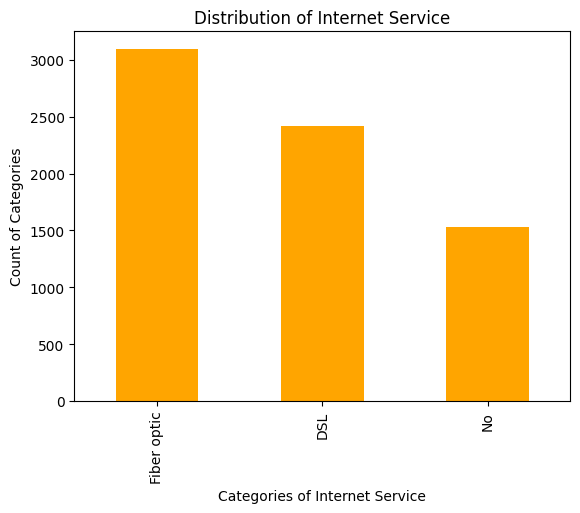

In [27]:
df['InternetService'].value_counts().plot(kind='bar', color='orange')

plt.xlabel("Categories of Internet Service")
plt.ylabel("Count of Categories")
plt.title("Distribution of Internet Service")

plt.show()

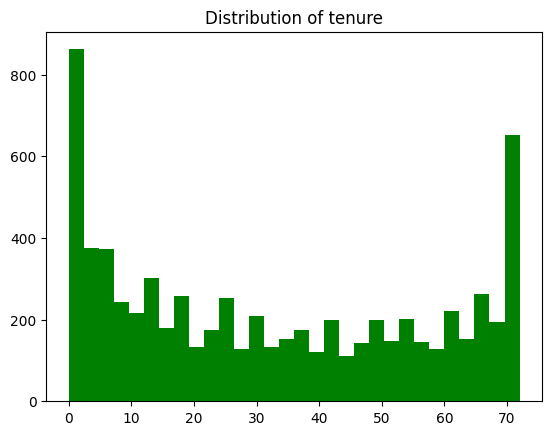

In [31]:




plt.hist(df['tenure'],bins=30,color='green')

plt.title("Distribution of tenure")

plt.show()





In [ ]:
● Build a scatter-plot between ‘MonthlyCharges’ and ‘tenure’. Map ‘MonthlyCharges’ to the y-axis and ‘tenure’ to the ‘x-axis’:

a. Assign the points a color of ‘brown’

b. Set the x-axis label to ‘Tenure of customer’

c. Set the y-axis label to ‘Monthly Charges of customer’

d. Set the title to ‘Tenure vs Monthly Charges’



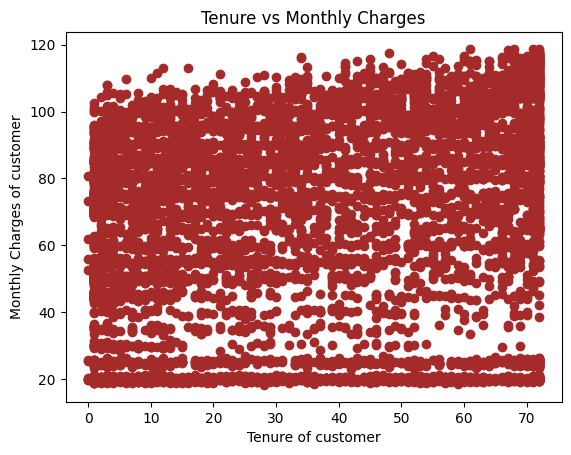

In [32]:
plt.scatter(df['tenure'], df['MonthlyCharges'], color='brown')

plt.xlabel("Tenure of customer")
plt.ylabel("Monthly Charges of customer")
plt.title("Tenure vs Monthly Charges")

plt.show()

<Axes: xlabel='Contract', ylabel='tenure'>

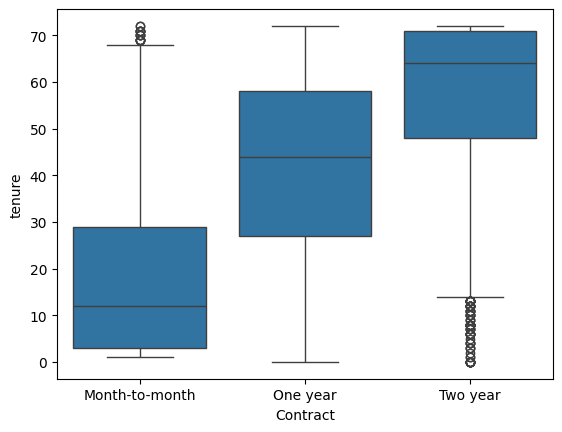

In [33]:
sns.boxplot(x=df['Contract'], y=df['tenure'])

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [35]:
X = df[['tenure']]
y = df['MonthlyCharges']

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)